# MFAA Chapter 7 Laboratory
**Indifference Pricing Engine** (book §7.9)

Price unspanned claims with the full nonlinear toolkit — indifference, good-deal, convex-risk-measure, BSDE — side by side. The organizing display is the operator ladder. Seed `20260700`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch07
from dataclasses import replace

## 1. The operator ladder (Exercise 7.10)
Containment: π ≤ π_gd ≤ p_b/q ≤ π_lin ≤ p_s/q ≤ π_gd ≤ π̄, straddling the Davis price.

In [2]:
lad = ch07.operator_ladder(ch07.ClaimParams())
for k,v in lad['ladder'].items(): print(f'  {k:10s} {v:.4f}')
print('ordering holds:', lad['ordering_holds'])

  pi_low     0.6667
  gd_low     0.9524
  p_b        1.0738
  linear     1.0952
  p_s        1.1167
  gd_high    1.2381
  pi_bar     1.5238
  davis      1.0952
ordering holds: True


## 2. Demand curve: per-unit prices vs position size (Figure 7.1)

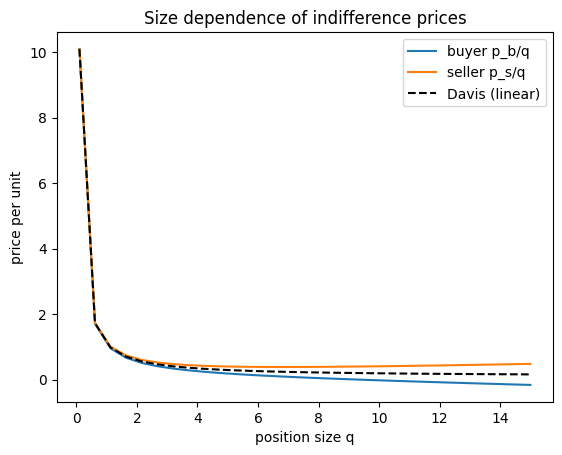

In [3]:
rows = ch07.demand_curve(ch07.ClaimParams())
q=[r['q'] for r in rows]
plt.plot(q,[r['buyer_per_unit'] for r in rows],label='buyer p_b/q')
plt.plot(q,[r['seller_per_unit'] for r in rows],label='seller p_s/q')
plt.plot(q,[r['davis'] for r in rows],'k--',label='Davis (linear)')
plt.xlabel('position size q'); plt.ylabel('price per unit'); plt.legend(); plt.title('Size dependence of indifference prices');

The buyer–seller gap is a variance bill: p_s − p_b = γσ_e²q²/R. Only the residual variance is charged — the hedgeable fraction is free.

## 3. E1 — hedgeable-fraction sweep
Move variance from residual to spanned; watch [p_b, p_s] collapse onto replication.

In [4]:
for se in (0.5, 0.3, 0.1, 0.02):
    ind = ch07.indifference_prices(replace(ch07.ClaimParams(), sigma_e=se))
    print(f'sigma_e={se}: variance bill {ind["variance_bill"]:.4f}')

sigma_e=0.5: variance bill 0.1190
sigma_e=0.3: variance bill 0.0429
sigma_e=0.1: variance bill 0.0048
sigma_e=0.02: variance bill 0.0002


## 4. Validation checks

In [5]:
v = ch07.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

V1_variance_bill PASS
V2_ladder_ordering PASS
V3_davis_limit PASS
V4_ce_match PASS
V5_hedgeable_collapse PASS
V6_bsde_entropic PASS
ALL: True
